CODE BEGINS!!!

In [ ]:
import numpy as np


In [4]:
import pandas as pd


In [6]:
import matplotlib.pyplot as plt

In [8]:
import seaborn as sns

In [10]:
# Load dataset
df = pd.read_csv("loan_data.csv")


In [12]:
# View first 5 rows
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [14]:
# Shape of dataset
df.shape


(614, 13)

In [16]:
# Dataset information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [18]:
df.isnull().sum()


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [20]:
df.columns


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [22]:
df.index

RangeIndex(start=0, stop=614, step=1)

In [24]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])





In [26]:
df.isnull().sum()


Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [28]:
df.select_dtypes(include='object').columns


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [30]:
print(df.columns)


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])


In [34]:
df['Gender'] = le.fit_transform(df['Gender'])
df['Married'] = le.fit_transform(df['Married'])
df['Education'] = le.fit_transform(df['Education'])
df['Self_Employed'] = le.fit_transform(df['Self_Employed'])


In [36]:
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)


In [38]:
df['Property_Area'] = le.fit_transform(df['Property_Area'])


In [42]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


In [62]:
if 'Loan_ID' in df.columns:
    df = df.drop('Loan_ID', axis=1)


In [64]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']


In [66]:
print(X.dtypes)


Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
dtype: object


In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
print(X_train.dtypes)


Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
dtype: object


In [74]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(491, 11)
(123, 11)
(491,)
(123,)


In [76]:
df.isnull().sum()


Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [78]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())
df['Dependents'] = df['Dependents'].replace('3+', 3)  # Convert '3+' to 3
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])


In [80]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
print(np.isnan(X_train_scaled).sum())

0


In [84]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [86]:
# Predict on test data
y_pred = model.predict(X_test_scaled)



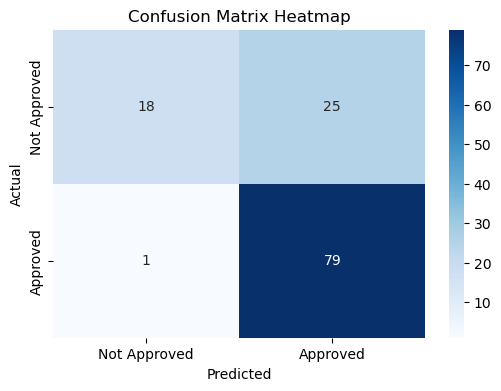

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Approved','Approved'], yticklabels=['Not Approved','Approved'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Heatmap')
plt.show()


In [90]:
import shap

# Create an explainer using your trained model
explainer = shap.Explainer(model, X_train_scaled)  # X_train_scaled = your scaled training data

# Calculate SHAP values for the test set
shap_values = explainer(X_test_scaled)  # X_test_scaled = your scaled test data



In [678]:
import pickle
with open("loan_prediction_model.pkl", "wb") as file:
    pickle.dump(model, file)
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)



In [92]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7886178861788617



Enter applicant details:


Applicant Income:  34
Coapplicant Income:  43
Loan Amount:  344
Loan Term (in months):  34
Credit History (1=Yes, 0=No):  1
Gender (Male/Female):  m
Married (Yes/No):  y
Education (Graduate/Not Graduate):  e
Self Employed (Yes/No):  y
Property Area (Urban/Semiurban/Rural):  s
Dependents (0/1/2/3+):  2



✅ Loan Approved

Feature importance for this decision:


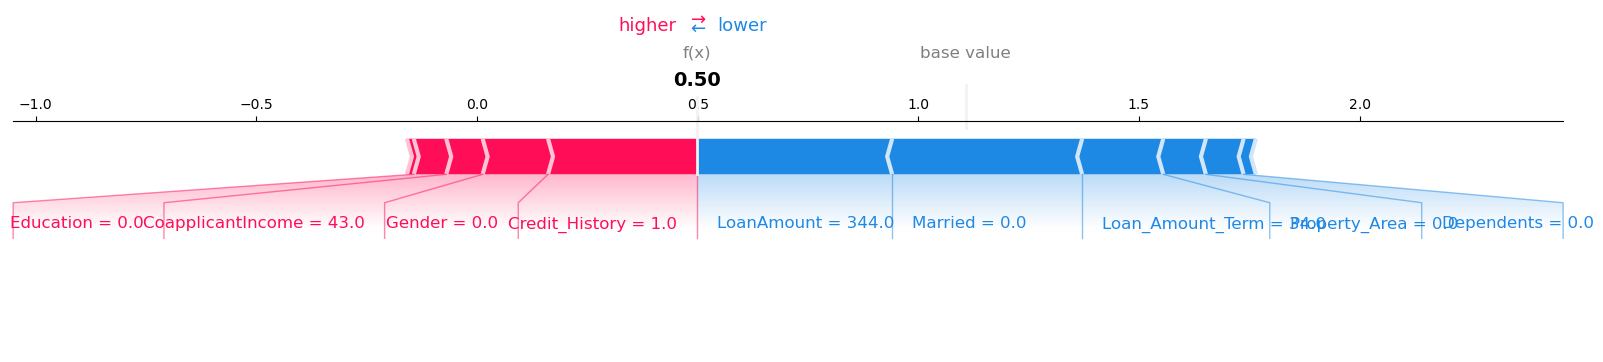


Check another applicant? (yes/no):  y


In [680]:
def check_loan_status():
    while True:
        print("\nEnter applicant details:")
        
        applicant_data = {
            'ApplicantIncome': float(input("Applicant Income: ")),
            'CoapplicantIncome': float(input("Coapplicant Income: ")),
            'LoanAmount': float(input("Loan Amount: ")),
            'Loan_Amount_Term': float(input("Loan Term (in months): ")),
            'Credit_History': int(input("Credit History (1=Yes, 0=No): ")),
            'Gender': input("Gender (Male/Female): "),
            'Married': input("Married (Yes/No): "),
            'Education': input("Education (Graduate/Not Graduate): "),
            'Self_Employed': input("Self Employed (Yes/No): "),
            'Property_Area': input("Property Area (Urban/Semiurban/Rural): "),
            'Dependents': input("Dependents (0/1/2/3+): ")
        }
        
        # Convert to dataframe
        df_input = pd.DataFrame([applicant_data])

        # Encode categorical variables
        df_input = pd.get_dummies(df_input)
        
        
        
        # Ensure all columns present
        for col in X.columns:
            if col not in df_input.columns:
                df_input[col] = 0
        
        # Reorder columns
        df_input = df_input[X.columns]
        
        # Scale
        input_scaled = scaler.transform(df_input)
        
        # Predict
        pred = model.predict(input_scaled)[0]
        print("\n✅ Loan Approved" if pred==1 else "\n❌ Loan Not Approved")

        # SHAP explanation
        shap_values = explainer.shap_values(input_scaled)
        print("\nFeature importance for this decision:")
        shap.initjs()
        shap.force_plot(explainer.expected_value, shap_values, df_input, matplotlib=True)
        plt.show()
        
        # Ask if user wants to check another applicant
        again = input("\nCheck another applicant? (yes/no): ").lower()
        if again != "yes":
            break

# ✅ Run the interactive function
check_loan_status()



Enter applicant details:


Applicant Income:  45
Coapplicant Income:  32
Loan Amount:  455
Loan Term (in months):  45
Credit History (1=Yes, 0=No):  1
Gender (Male/Female):  f
Married (Yes/No):  y
Education (Graduate/Not Graduate):  g
Self Employed (Yes/No):  y
Property Area (Urban/Semiurban/Rural):  u
Dependents (0/1/2/3+):  5



✅ Loan Approved

Important factors for this decision:
Gender : 0.148
Married : -0.431
Dependents : -0.085
Education : 0.074
Self_Employed : -0.028
ApplicantIncome : 0.015
CoapplicantIncome : 0.083
LoanAmount : -0.687
Loan_Amount_Term : -0.177
Credit_History : 0.338
Property_Area : -0.097


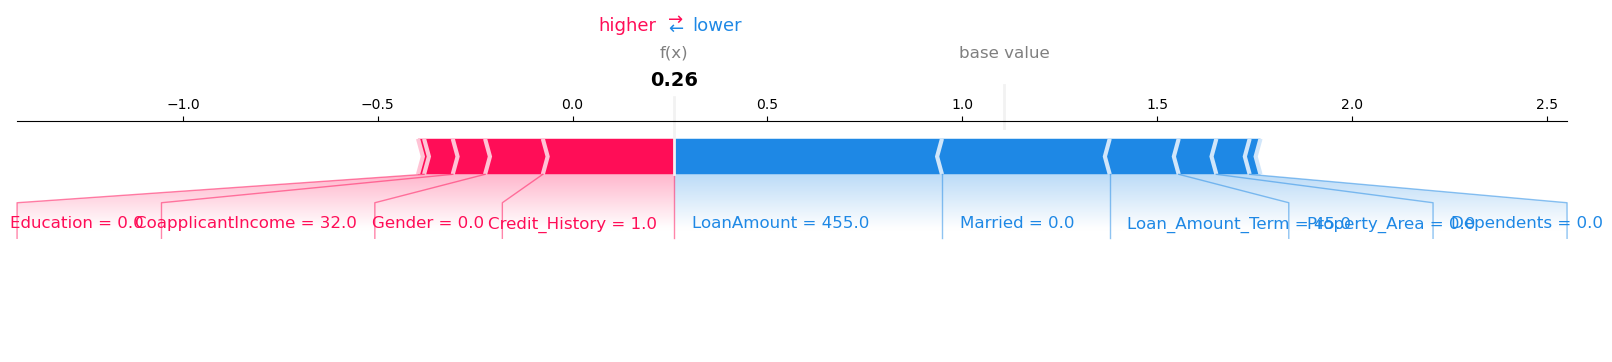

In [ ]:
def check_loan_status():
    while True:
        print("\nEnter applicant details:")
        
        applicant_data = {
            'ApplicantIncome': float(input("Applicant Income: ")),
            'CoapplicantIncome': float(input("Coapplicant Income: ")),
            'LoanAmount': float(input("Loan Amount: ")),
            'Loan_Amount_Term': float(input("Loan Term (in months): ")),
            'Credit_History': int(input("Credit History (1=Yes, 0=No): ")),
            'Gender': input("Gender (Male/Female): "),
            'Married': input("Married (Yes/No): "),
            'Education': input("Education (Graduate/Not Graduate): "),
            'Self_Employed': input("Self Employed (Yes/No): "),
            'Property_Area': input("Property Area (Urban/Semiurban/Rural): "),
            'Dependents': input("Dependents (0/1/2/3+): ")
        }
        
        # Convert to dataframe
        df_input = pd.DataFrame([applicant_data])

        # Encode categorical variables
        df_input = pd.get_dummies(df_input)
        
        # Ensure all columns present
        for col in X.columns:
            if col not in df_input.columns:
                df_input[col] = 0
        
        # Reorder columns
        df_input = df_input[X.columns]
        
        # Scale
        input_scaled = scaler.transform(df_input)
        
        # Predict
        pred = model.predict(input_scaled)[0]
        print("\n✅ Loan Approved" if pred==1 else "\n❌ Loan Not Approved")

        # =========================
        # SHAP Explanation Section
        # =========================
        shap_values = explainer.shap_values(input_scaled)

        print("\nImportant factors for this decision:")

        # Convert SHAP values to readable feature importance
        feature_imp = shap_values[0]

        for i, col in enumerate(df_input.columns):
            print(f"{col} : {round(feature_imp[i], 3)}")

        # SHAP Graph
        shap.initjs()
        shap.force_plot(explainer.expected_value, shap_values, df_input, matplotlib=True)
        plt.show()
        
        # Ask if user wants to check another applicant
        again = input("\nCheck another applicant? (yes/no): ").lower()
        if again != "yes":
            break

# Run
check_loan_status()